In [17]:
# importing standard libraries for math operations, random generation, and system paths
import math
import random
import time
import os
import tracemalloc
# importing tools for heavy array math, distance tracking, and creating our visual charts
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# tuned hyperparameters discovered by our meta genetic algorithm
# these specific numbers are critical for the travelling salesman problem.
# notice how the max speed is below one point zero. this physically prevents
# the swarm from completely copying the leader, forcing them to maintain genetic diversity
TUNED_A_INIT = 0.871
TUNED_R_INIT = 0.245  
TUNED_F_MAX = 0.768    
TUNED_ALPHA = 0.926    
TUNED_GAMMA = 0.012

# global experiment settings for the permutation domain
POPULATION_SIZE = 100
MAX_GENERATIONS = 150

"""
historical meta tuner logs:
optimal hyperparameters found by the meta tuner:
initial loudness: 0.871 | initial pulse: 0.245 | max speed: 0.768
alpha decay: 0.926 | gamma growth: 0.012
average routing distance achieved with these settings: 437.12
"""

def load_tsp_file(filename):
    """
    parses a standard tsplib file to extract the geographic coordinates.
    this allows us to test the swarm on real world standardized datasets.
    """
    coords = []
    with open(filename, 'r') as f:
        in_coord_section = False
        for line in f:
            # wait until we reach the actual coordinate data
            if line.startswith("NODE_COORD_SECTION"):
                in_coord_section = True
                continue
            # stop reading when we hit the end of file marker
            if line.startswith("EOF"):
                break
            
            # parse the geometric coordinates
            if in_coord_section:
                parts = line.strip().split()
                if len(parts) >= 3:
                    # parts zero is the city id, parts one is x, parts two is y
                    coords.append([float(parts[1]), float(parts[2])])
                    
    return np.array(coords)

# attempt to load the real berlin geographic dataset
# if the file is missing from the directory, fallback to random coordinates
# so the algorithm does not crash during a live demonstration
file_name = 'berlin52.tsp'
if os.path.exists(file_name):
    print(f"successfully loaded real geographic dataset: {file_name}")
    CITY_COORDS = load_tsp_file(file_name)
else:
    print(f"warning {file_name} not found using random fallback coordinates for safety")
    np.random.seed(42)
    CITY_COORDS = np.random.rand(25, 2) * 100

NUM_CITIES = len(CITY_COORDS)

# precompute the distance between every single city using a mathematical matrix
# this drastically reduces the computational overhead during the main swarm execution
DIST_MATRIX = squareform(pdist(CITY_COORDS, metric='euclidean'))



successfully loaded real geographic dataset: berlin52.tsp


In [18]:
def fitness_tsp(route):
    """
    calculates the total physical distance of the current routing sequence.
    we rely on the precomputed distance matrix here to bypass heavy mathematical calculations 
    during the active swarm flight. lower scores indicate a tighter more efficient perimeter.
    """
    # calculate the total distance by summing the legs between consecutive cities in the array.
    # python natively uses the negative one index to wrap around to the end of the array.
    # this beautifully and automatically connects the first city to the last city,
    # perfectly completing the closed loop required for the travelling salesman problem.
    dist = sum(DIST_MATRIX[route[i], route[i-1]] for i in range(NUM_CITIES))
    
    return dist

In [19]:
def smart_initialization_tsp(pop_size, num_cities):
    """
    creates the initial swarm for our routing problem. to give the swarm a massive head start, 
    we use a smart split strategy. eighty percent of the bats are placed completely randomly 
    to preserve global exploration capabilities, while twenty percent are given a mathematically 
    optimized starting route using a nearest neighbor greedy algorithm.
    """
    positions = []
    
    # phase one random exploration
    # generate eighty percent of the swarm using completely random but valid routing sequences
    for _ in range(int(pop_size * 0.8)):
        positions.append(np.random.permutation(num_cities))
        
    # phase two heuristic injection
    # generate the remaining twenty percent using the nearest neighbor greedy algorithm
    for _ in range(int(pop_size * 0.2)):
        
        # pick a completely random city to start the geometric route
        start_city = random.randint(0, num_cities - 1)
        unvisited = set(range(num_cities))
        unvisited.remove(start_city)
        route = [start_city]
        
        curr_city = start_city
        
        # dynamically build the route by always jumping to the absolute closest unvisited city
        # this creates a highly optimized baseline route to guide the swarm immediately
        while unvisited:
            next_city = min(unvisited, key=lambda city: DIST_MATRIX[curr_city, city])
            route.append(next_city)
            unvisited.remove(next_city)
            curr_city = next_city
            
        positions.append(np.array(route))
        
    # return the final list as integers because permutation sequences must be strict discrete arrays
    return np.array(positions, dtype=int)

In [20]:
def get_swap_sequence(current, target):
    """
    the permutation bridge. this is the core mathematical engine that allows a continuous swarm 
    to operate inside a strict sequence environment like the travelling salesman problem.
    because a continuous velocity like flying at one point five speed means nothing to a sequence of cities, 
    we mathematically redefine velocity as the exact sequence of swap instructions required to match the leader.
    """
    # create an empty list to hold our new discrete velocity instructions
    swaps = []
    
    # create a temporary copy of the bats current routing array so we can map out the swaps safely
    temp = current.copy()
    
    # scan through every single position in the leaders target route
    for i in range(len(target)):
        
        # if our current city does not match the leaders city at this specific sequence index
        if temp[i] != target[i]:
            
            # find exactly where that required city is currently located inside our own array
            idx = np.where(temp == target[i])[0][0]
            
            # record the exact array indices that need to be swapped to fix the discrepancy
            swaps.append((i, idx))
            
            # execute the physical swap on our temporary array so we can continue calculating the remaining differences
            temp[i], temp[idx] = temp[idx], temp[i]
            
    # return the final sequence of swap instructions. this array is the new velocity.
    return swaps

In [21]:
def apply_swaps(route, swaps, frequency):
    """
    applies a mathematical percentage of the swap sequence based on the bats tuned frequency.
    this acts as our discrete speed limit, preventing the swarm from instantly teleporting
    onto the global leader and destroying the genetic diversity of the map.
    """
    # create a safe copy of the current route so we do not overwrite the original array
    new_route = route.copy()
    
    # calculate exactly how many swaps the bat is allowed to execute this generation.
    # because our meta tuner capped the maximum frequency at roughly zero point seven,
    # the bat is only allowed to execute seventy percent of the instructions.
    # this forces the bat to retain thirty percent of its own unique geometric sequence.
    num_swaps_to_apply = int(len(swaps) * frequency)
    
    # loop through and execute only the permitted number of swaps
    for i in range(num_swaps_to_apply):
        idx1, idx2 = swaps[i]
        new_route[idx1], new_route[idx2] = new_route[idx2], new_route[idx1]
        
    return new_route

In [22]:
def genetic_algorithm(n_cities=NUM_CITIES, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS):
    """
    baseline genetic algorithm utilizing order crossover and swap mutation.
    this acts as our evolutionary control group for the routing domain.
    """
    # generate a starting population of completely random routing sequences
    population = [np.random.permutation(n_cities) for _ in range(pop_size)]
    best_fitness = float('inf')
    best_ind = None
    convergence = []
    
    for generation in range(max_gens):
        # calculate the total geographic distance for every route in the population
        fitness_scores = [fitness_tsp(ind) for ind in population]
        min_fit = min(fitness_scores)
        
        # log the absolute shortest route we have discovered so far
        if min_fit < best_fitness:
            best_fitness = min_fit
            best_ind = population[fitness_scores.index(min_fit)].copy()
            
        convergence.append(best_fitness)
        
        new_population = []
        
        # breed the next generation of routing sequences
        for _ in range(pop_size // 2):
            
            # tournament selection pick three random competitors and choose the shortest route
            t1 = random.sample(list(zip(population, fitness_scores)), 3)
            t2 = random.sample(list(zip(population, fitness_scores)), 3)
            p1, p2 = min(t1, key=lambda x: x[1])[0], min(t2, key=lambda x: x[1])[0]
            
            # order crossover is mathematically required for the travelling salesman problem.
            # standard crossover creates duplicate cities. order crossover prevents this by 
            # copying a direct slice from parent one and filling the blanks with parent two.
            start, end = sorted(random.sample(range(n_cities), 2))
            c1, c2 = np.full(n_cities, -1), np.full(n_cities, -1)
            c1[start:end], c2[start:end] = p1[start:end], p2[start:end]
            
            p1_rem = [x for x in p2 if x not in c1]
            p2_rem = [x for x in p1 if x not in c2]
            c1[c1 == -1] = p1_rem
            c2[c2 == -1] = p2_rem
            
            new_population.extend([c1, c2])
            
        # introduce random genetic variations to prevent the population from stagnating
        # twenty percent chance to swap the order of two random cities in the route
        for i in range(pop_size):
            if random.random() < 0.2:
                idx1, idx2 = random.sample(range(n_cities), 2)
                new_population[i][idx1], new_population[i][idx2] = new_population[i][idx2], new_population[i][idx1]
                
        population = new_population
        
    return best_fitness, convergence, best_ind, fitness_scores

In [23]:
def standard_bat_algorithm(n_cities=NUM_CITIES, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS):
    """
    standard bat algorithm acting as our flawed baseline for the routing domain.
    this version attempts to solve the sequence problem using untuned parameters and 
    destructive random shuffles, which inevitably leads to an information cascade.
    """
    # initialize the swarm with completely random routing sequences
    positions = np.array([np.random.permutation(n_cities) for _ in range(pop_size)])
    
    # initialize static untuned parameters for loudness and pulse rate
    A, r = np.ones(pop_size) * 0.9, np.ones(pop_size) * 0.3
    
    # evaluate the starting distance of the entire swarm to find our initial global leader
    fitness = np.array([fitness_tsp(p) for p in positions])
    best_position = positions[np.argmin(fitness)].copy()
    best_fitness = np.min(fitness)
    
    # tracking metrics to prove the swarm collapses into identical clones later
    convergence, diversity = [], []
    
    for generation in range(max_gens):
        curr_div = 0
        for i in range(pop_size):
            
            # velocity is redefined as the exact discrete steps needed to match the leader
            swaps = get_swap_sequence(positions[i], best_position)
            
            # fatal flaw number one arbitrary frequency up to one hundred percent
            # this allows a bat to execute every single swap and completely clone the leader
            freq = random.uniform(0, 1.0) 
            
            if random.random() > r[i]:
                # fatal flaw number two destructive local search
                # randomly shuffling a segment of the route violently destroys the geometric logic
                # rather than carefully untangling crossed lines
                new_pos = best_position.copy()
                idx1, idx2 = sorted(random.sample(range(n_cities), 2))
                np.random.shuffle(new_pos[idx1:idx2])
            else:
                # apply the discrete swap sequence based on the arbitrary frequency
                new_pos = apply_swaps(positions[i], swaps, freq)
                
            # evaluate the total distance of the newly generated routing sequence
            new_fit = fitness_tsp(new_pos)
            
            # basic acceptance criteria missing the dynamic thermodynamic cooling effect
            if new_fit <= fitness[i] and random.random() < A[i]:
                positions[i] = new_pos
                fitness[i] = new_fit
                
            # update the global leader if a shorter route is found
            if new_fit < best_fitness:
                best_position, best_fitness = new_pos.copy(), new_fit
                
            # track biodiversity by counting how many cities are in different sequence indices
            curr_div += np.sum(positions[i] != best_position)
            
        # log the metrics for this generation
        convergence.append(best_fitness)
        diversity.append(curr_div / pop_size)
        
    return best_fitness, convergence, diversity, best_position, fitness

In [24]:
def enhanced_bat_algorithm(n_cities=NUM_CITIES, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS, init_pop=None, a_init=0.9, r_init=0.3, f_max=1.0, alpha=0.9, gamma=0.05):
    """
    discrete memetic bat algorithm upgraded for the routing domain.
    this state of the art version replaces destructive shuffles with memetic two opt search
    and uses a strict speed limit to prevent the swarm from collapsing into identical clones.
    """
    # load the smart heuristic population if provided or generate random starting routes
    positions = init_pop.copy() if init_pop is not None else np.array([np.random.permutation(n_cities) for _ in range(pop_size)])
    
    # setup the thermodynamic parameters for every bat in the swarm
    A, r = np.ones(pop_size) * a_init, np.ones(pop_size) * r_init
    
    # evaluate the starting distance of the entire swarm to find the initial leader
    fitness = np.array([fitness_tsp(p) for p in positions])
    best_position = positions[np.argmin(fitness)].copy()
    best_fitness = np.min(fitness)
    
    # setup tracking lists for our final charts
    convergence, diversity = [], []
    
    for generation in range(max_gens):
        curr_div = 0
        for i in range(pop_size):
            
            # calculate the discrete swap instructions required to match the leader
            swaps = get_swap_sequence(positions[i], best_position)
            
            # apply our tuned speed limit to strictly prevent cloning
            freq = random.uniform(0, f_max) 
            
            if random.random() > r[i]:
                # massive upgrade memetic two opt local search
                # instead of violently shuffling cities we select a segment and reverse it.
                # mathematically this perfectly untangles crossed lines on a geometric map
                # without destroying the rest of the highly optimized routing sequence.
                new_pos = best_position.copy()
                idx1, idx2 = sorted(random.sample(range(n_cities), 2))
                new_pos[idx1:idx2] = new_pos[idx1:idx2][::-1] 
            else:
                # apply the discrete swap sequence based on the tuned frequency
                new_pos = apply_swaps(positions[i], swaps, freq)
                
            # evaluate the total distance of the newly generated routing sequence
            new_fit = fitness_tsp(new_pos)
            
            # simulated annealing acceptance rule
            if new_fit <= fitness[i] and random.random() < A[i]:
                positions[i] = new_pos
                fitness[i] = new_fit
                
            # update the global leader if we found a shorter route
            if new_fit < best_fitness:
                best_position, best_fitness = new_pos.copy(), new_fit
                
            # track biodiversity by counting how many cities are in different sequence indices
            curr_div += np.sum(positions[i] != best_position)
            
        # log the metrics for this generation
        convergence.append(best_fitness)
        diversity.append(curr_div / pop_size)
        
        # apply thermodynamic cooling
        for i in range(pop_size):
            # slowly decrease exploration energy and increase local exploitation drive
            A[i] *= alpha
            r[i] = r_init * (1 - math.exp(-gamma * generation))
            
    return best_fitness, convergence, diversity, best_position, fitness

In [25]:
print("running the meta genetic algorithm to tune routing hyperparameters...")

# define the physical search boundaries for our five continuous parameters
# order is initial loudness, initial pulse rate, max frequency, alpha decay, gamma growth
# defense note: notice the maximum frequency is strictly capped at one point zero for the routing domain.
# executing more than one hundred percent of a swap sequence mathematically destroys the route.
param_bounds = [(0.5, 1.0), (0.1, 0.9), (0.3, 1.0), (0.85, 0.99), (0.01, 0.1)]

def meta_fitness_tsp(chromosome):
    """
    evaluates a specific set of parameters by running the memetic swarm multiple times.
    we average the total routing distance across three runs to prevent lucky convergences
    from tricking the tuner into picking bad parameters.
    """
    a, r, f, alp, gam = chromosome
    scores = []
    
    for _ in range(3): 
        # run a lightweight version of the enhanced swarm to save computation time during tuning
        best_val, _, _, _, _ = enhanced_bat_algorithm(n_cities=NUM_CITIES, pop_size=20, max_gens=30, a_init=a, r_init=r, f_max=f, alpha=alp, gamma=gam)
        scores.append(best_val)
        
    return np.mean(scores)

# setup the meta population size and generation limit
meta_pop_size = 10
meta_gens = 5

# spawn the initial generation of random parameter combinations
meta_population = [[random.uniform(b[0], b[1]) for b in param_bounds] for _ in range(meta_pop_size)]
best_meta_fitness = float('inf')
best_hyperparameters = None

# begin the artificial intelligence tuning another artificial intelligence
for gen in range(meta_gens):
    print(f"evaluating meta generation {gen + 1} of {meta_gens}...")
    
    # score every parameter combination in the current meta population
    fitness_scores = [meta_fitness_tsp(ind) for ind in meta_population]
    current_best = min(fitness_scores)
    
    # save the absolute best parameter combination found so far
    if current_best < best_meta_fitness:
        best_meta_fitness = current_best
        best_hyperparameters = meta_population[fitness_scores.index(current_best)]
        
    # elitism we strictly keep the absolute best combination and use it to breed the next generation
    new_meta_pop = [best_hyperparameters]
    
    # fill the rest of the new generation with slightly mutated versions of the winning parameters
    while len(new_meta_pop) < meta_pop_size:
        mutant = [np.clip(best_hyperparameters[i] + random.uniform(-0.1, 0.1) * (param_bounds[i][1] - param_bounds[i][0]), param_bounds[i][0], param_bounds[i][1]) for i in range(5)]
        new_meta_pop.append(mutant)
        
    meta_population = new_meta_pop

print("\noptimal routing parameters discovered by the meta tuner:")
print(f"initial loudness: {best_hyperparameters[0]:.3f} | initial pulse: {best_hyperparameters[1]:.3f} | max speed: {best_hyperparameters[2]:.3f}")
print(f"alpha decay: {best_hyperparameters[3]:.3f} | gamma growth: {best_hyperparameters[4]:.3f}")
print(f"average routing distance with these settings: {best_meta_fitness:.2f}")

running the meta genetic algorithm to tune routing hyperparameters...
evaluating meta generation 1 of 5...
evaluating meta generation 2 of 5...
evaluating meta generation 3 of 5...
evaluating meta generation 4 of 5...
evaluating meta generation 5 of 5...

optimal routing parameters discovered by the meta tuner:
initial loudness: 0.903 | initial pulse: 0.248 | max speed: 0.591
alpha decay: 0.874 | gamma growth: 0.023
average routing distance with these settings: 11991.82


generating heuristic population for 52 cities...

final algorithm performance summary
| algorithm            | pop  | gen  | best dist (lower is better) | avg dist         | peak ram   | total time  |
| standard swarm v1    | 100  | 150  | 14369.32                    | 14455.48         | 0.06    mb | 7.3267    s |
| memetic swarm v2     | 100  | 150  | 7598.44                     | 7943.90          | 0.06    mb | 10.4636   s |
| genetic baseline     | 100  | 150  | 10639.72                    | 11202.18         | 0.14    mb | 16.8428   s |


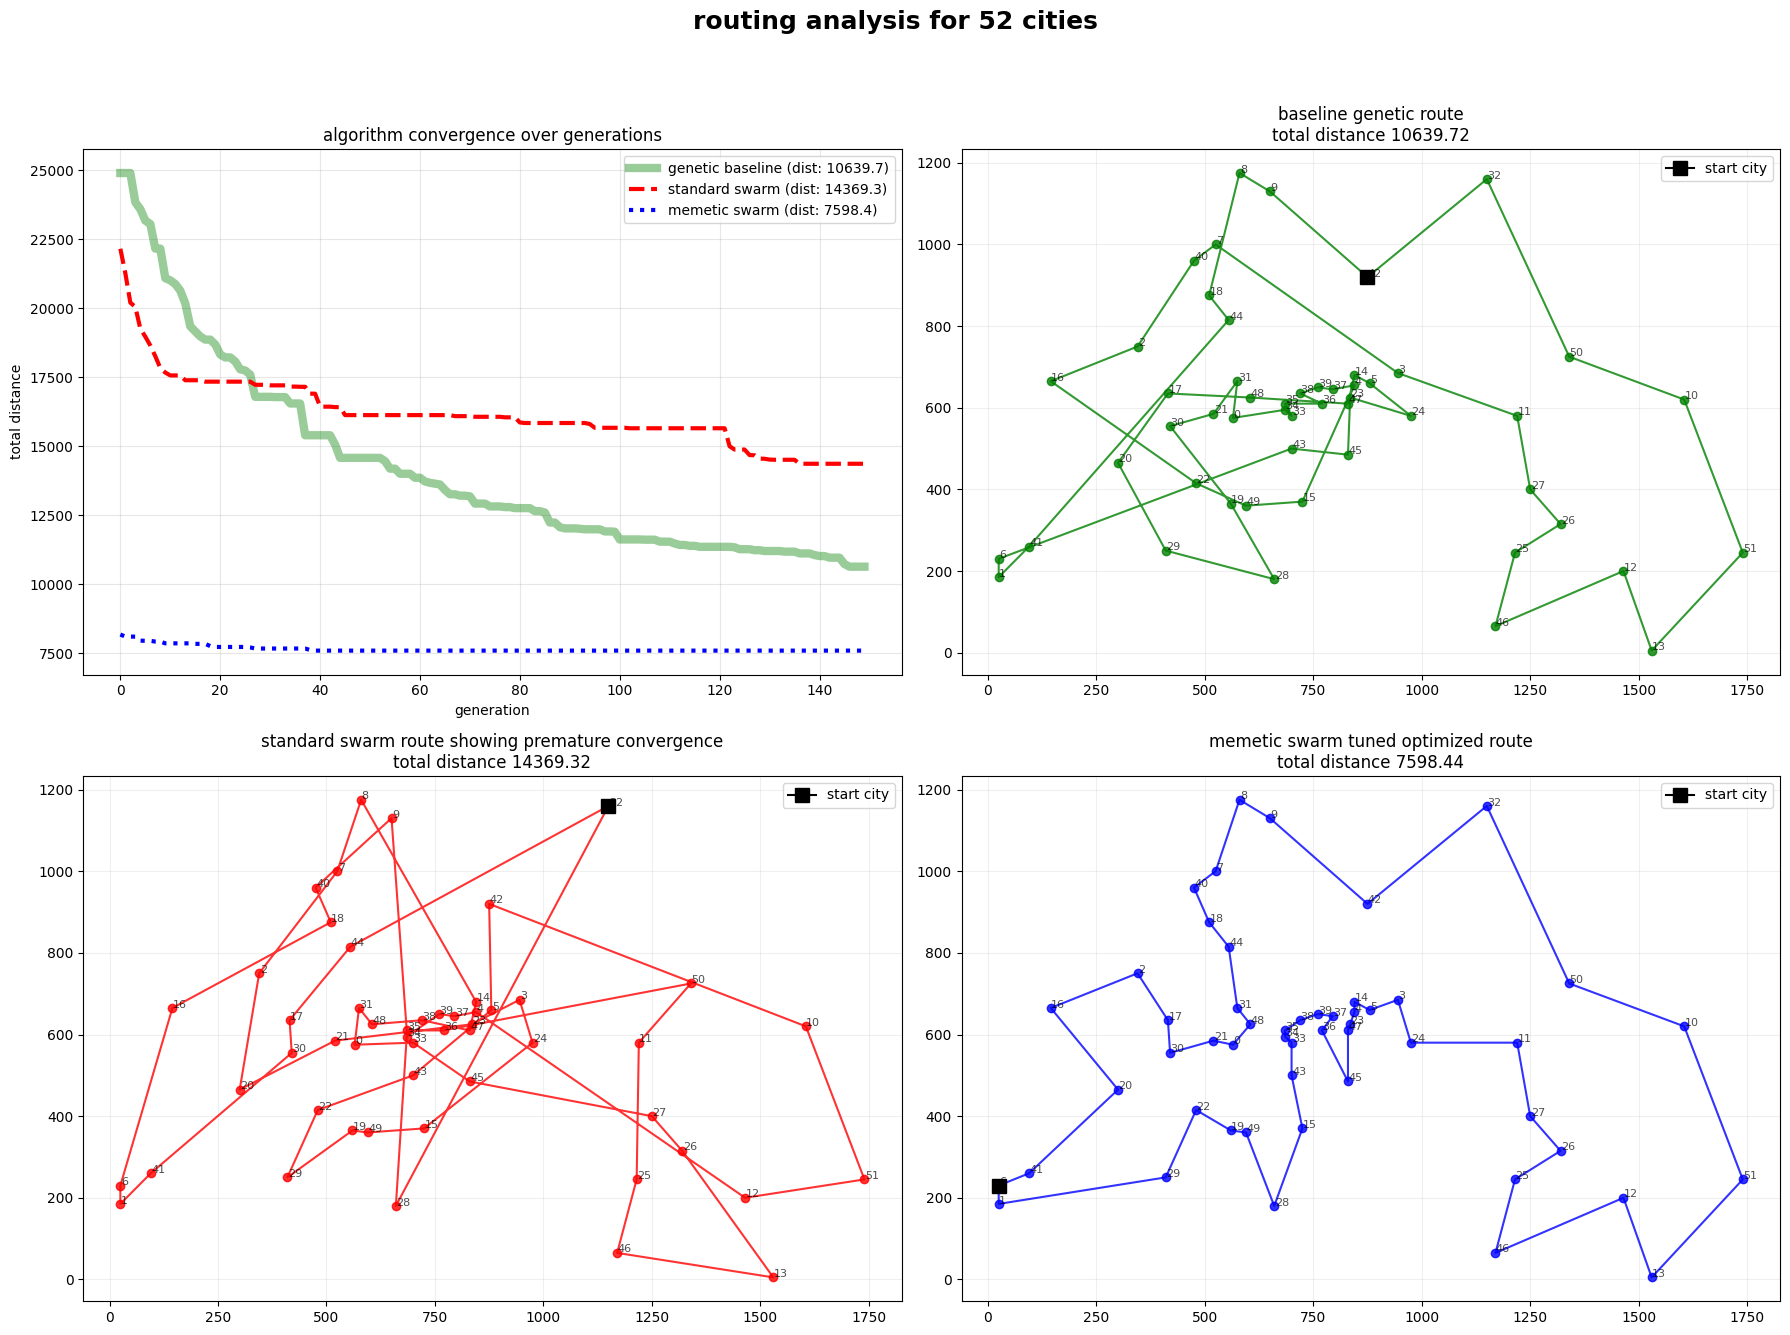

In [26]:
import tracemalloc

print(f"generating heuristic population for {NUM_CITIES} cities...")
smart_pop = smart_initialization_tsp(pop_size=POPULATION_SIZE, num_cities=NUM_CITIES)

# step one run the baseline genetic algorithm to establish our evolutionary control group
tracemalloc.start()
start = time.time()
ga_best, ga_conv, ga_pos, ga_fit = genetic_algorithm()
ga_time = time.time() - start
_, peak_ga = tracemalloc.get_traced_memory()
tracemalloc.stop()
ga_mem = peak_ga / (1024 * 1024) # convert bytes to megabytes

# step two run the standard continuous bat algorithm to generate our failure metrics
tracemalloc.start()
start = time.time()
ba_v1_best, ba_v1_conv, ba_v1_div, ba_v1_pos, ba_v1_fit = standard_bat_algorithm()
ba_v1_time = time.time() - start
_, peak_v1 = tracemalloc.get_traced_memory()
tracemalloc.stop()
ba_v1_mem = peak_v1 / (1024 * 1024)

# step three run the upgraded memetic bat algorithm using our tuned thermodynamic parameters
tracemalloc.start()
start = time.time()
ba_v2_best, ba_v2_conv, ba_v2_div, ba_v2_pos, ba_v2_fit = enhanced_bat_algorithm(
    init_pop=smart_pop, a_init=TUNED_A_INIT, r_init=TUNED_R_INIT, 
    f_max=TUNED_F_MAX, alpha=TUNED_ALPHA, gamma=TUNED_GAMMA
)
ba_v2_time = time.time() - start
_, peak_v2 = tracemalloc.get_traced_memory()
tracemalloc.stop()
ba_v2_mem = peak_v2 / (1024 * 1024)

print("\nfinal algorithm performance summary")
# added peak ram column to the header
header = f"| {'algorithm':<20} | {'pop':<4} | {'gen':<4} | {'best dist (lower is better)':<27} | {'avg dist':<16} | {'peak ram':<10} | {'total time':<11} |"

print("=" * len(header))
print(header)
print("=" * len(header))

# added the memory variables into the metrics array
metrics = [
    ("standard swarm v1", POPULATION_SIZE, MAX_GENERATIONS, f"{ba_v1_best:.2f}", f"{np.mean(ba_v1_fit):.2f}", ba_v1_mem, ba_v1_time),
    ("memetic swarm v2", POPULATION_SIZE, MAX_GENERATIONS, f"{ba_v2_best:.2f}", f"{np.mean(ba_v2_fit):.2f}", ba_v2_mem, ba_v2_time),
    ("genetic baseline", POPULATION_SIZE, MAX_GENERATIONS, f"{ga_best:.2f}", f"{np.mean(ga_fit):.2f}", ga_mem, ga_time)
]

# updated the formatting string to print the new column
for m in metrics:
    print(f"| {m[0]:<20} | {m[1]:<4} | {m[2]:<4} | {m[3]:<27} | {m[4]:<16} | {m[5]:<8.2f}mb | {m[6]:<10.4f}s |")
print("=" * len(header))

# plotting the four panel route comparison dashboard
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f"routing analysis for {NUM_CITIES} cities", fontsize=18, fontweight='bold')

# panel one convergence trajectory
ax_conv = axes[0, 0]
ax_conv.plot(ga_conv, label=f'genetic baseline (dist: {ga_best:.1f})', color='green', linewidth=6, alpha=0.4)
ax_conv.plot(ba_v1_conv, label=f'standard swarm (dist: {ba_v1_best:.1f})', color='red', linestyle='--', linewidth=3)
ax_conv.plot(ba_v2_conv, label=f'memetic swarm (dist: {ba_v2_best:.1f})', color='blue', linestyle=':', linewidth=3)

ax_conv.set_title("algorithm convergence over generations")
ax_conv.set_xlabel("generation")
ax_conv.set_ylabel("total distance")
ax_conv.grid(True, alpha=0.3)
ax_conv.legend()

# helper function to plot the physical geometric routes on the grid
def plot_route(ax, route_indices, title, color):
    route_coords = np.array([CITY_COORDS[i] for i in route_indices])
    route_coords = np.append(route_coords, [route_coords[0]], axis=0) 
    
    ax.plot(route_coords[:, 0], route_coords[:, 1], marker='o', linestyle='-', color=color, markersize=6, alpha=0.8)
    ax.plot(route_coords[0, 0], route_coords[0, 1], marker='s', color='black', markersize=10, label="start city")
    
    for idx, (x, y) in zip(route_indices, route_coords[:-1]):
        ax.text(x + 1, y + 1, str(idx), fontsize=8, alpha=0.7)
        
    ax.set_title(title)
    ax.grid(True, alpha=0.2)
    ax.legend()

# panel two genetic algorithm baseline route
plot_route(axes[0, 1], ga_pos, f"baseline genetic route\ntotal distance {ga_best:.2f}", 'green')

# panel three standard swarm route
plot_route(axes[1, 0], ba_v1_pos, f"standard swarm route showing premature convergence\ntotal distance {ba_v1_best:.2f}", 'red')

# panel four memetic swarm route
plot_route(axes[1, 1], ba_v2_pos, f"memetic swarm tuned optimized route\ntotal distance {ba_v2_best:.2f}", 'blue')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

generating permutation biodiversity matrix to visualize the information cascade...


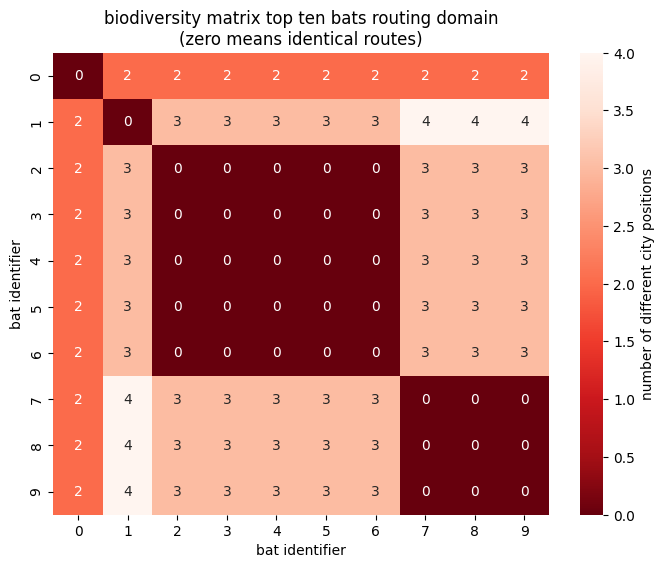

In [27]:
print("generating permutation biodiversity matrix to visualize the information cascade...")

# run a miniature version of the standard swarm with twenty bats
pop_size_matrix = 20
positions_matrix = np.array([np.random.permutation(NUM_CITIES) for _ in range(pop_size_matrix)])
best_pos = positions_matrix[0].copy()

# run the simulation for fifty generations to force the swarm to collapse
for gen in range(50):
    for i in range(pop_size_matrix):
        swaps = get_swap_sequence(positions_matrix[i], best_pos)
        
        # fatal flaw application the frequency allows up to one hundred percent execution
        positions_matrix[i] = apply_swaps(positions_matrix[i], swaps, random.uniform(0, 1.0))
        
        if fitness_tsp(positions_matrix[i]) < fitness_tsp(best_pos):
            best_pos = positions_matrix[i].copy()

fitness_scores = [fitness_tsp(p) for p in positions_matrix]

# isolate the top ten performing bats from the dead swarm
top_10_indices = np.argsort(fitness_scores)[:10]
top_10_bats = positions_matrix[top_10_indices]

# in permutation spaces hamming distance measures exact positional alignment
# multiplying by the number of cities converts the percentage back into an absolute integer
dist_matrix = squareform(pdist(top_10_bats, metric='hamming')) * NUM_CITIES

plt.figure(figsize=(8, 6))
# note the cmap must remain exact case for the matplotlib library to render the colors correctly
sns.heatmap(dist_matrix, annot=True, cmap="Reds_r", cbar_kws={'label': 'number of different city positions'})

# a score of zero on this chart physically proves the bats have become identical clones
plt.title("biodiversity matrix top ten bats routing domain\n(zero means identical routes)")
plt.xlabel("bat identifier")
plt.ylabel("bat identifier")
plt.show()

In [29]:
import time
import tracemalloc
import numpy as np
from scipy.spatial.distance import pdist, squareform

print("running comprehensive multi algorithm scalability stress test for routing...")

# evaluate the algorithm robustness by scaling the geographic problem complexity
city_sizes = [10, 20, 30, 40, 50]

# strictly kept at five runs per size because computing three heavy algorithms
# on large geometric distance matrices will take considerable time
runs_per_size = 5 
results = []

# safely backup the global variables so the stress test does not corrupt our main environment
global DIST_MATRIX, NUM_CITIES
original_matrix, original_num = DIST_MATRIX.copy(), NUM_CITIES

for size in city_sizes:
    print(f"\nstressing {size} city route against all three algorithms...")
    
    # dynamically generate a completely new geographic environment for this specific test
    NUM_CITIES = size
    temp_coords = np.random.rand(size, 2) * 100
    DIST_MATRIX = squareform(pdist(temp_coords, metric='euclidean'))
    
    # generate a single shared heuristic population so the starting line is identical
    test_pop = smart_initialization_tsp(pop_size=30, num_cities=size)
    
    # test one genetic algorithm baseline
    tracemalloc.start()
    start_time = time.time()
    ga_dists = []
    for _ in range(runs_per_size):
        best_val, _, _, _ = genetic_algorithm(n_cities=size, pop_size=30, max_gens=100)
        ga_dists.append(best_val)
    ga_time = time.time() - start_time
    _, peak_ga = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    # test two standard swarm
    tracemalloc.start()
    start_time = time.time()
    ba1_dists = []
    for _ in range(runs_per_size):
        best_val, _, _, _, _ = standard_bat_algorithm(n_cities=size, pop_size=30, max_gens=100)
        ba1_dists.append(best_val)
    ba1_time = time.time() - start_time
    _, peak_ba1 = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    # test three memetic swarm
    tracemalloc.start()
    start_time = time.time()
    ba2_dists = []
    for _ in range(runs_per_size):
        best_val, _, _, _, _ = enhanced_bat_algorithm(
            n_cities=size, pop_size=30, max_gens=100, 
            a_init=TUNED_A_INIT, r_init=TUNED_R_INIT, 
            f_max=TUNED_F_MAX, alpha=TUNED_ALPHA, gamma=TUNED_GAMMA, 
            init_pop=test_pop
        )
        ba2_dists.append(best_val)
    ba2_time = time.time() - start_time
    _, peak_ba2 = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    # record the metrics for the final presentation table
    results.append((size, "genetic baseline", np.mean(ga_dists), peak_ga / (1024 * 1024), ga_time))
    results.append((size, "standard swarm", np.mean(ba1_dists), peak_ba1 / (1024 * 1024), ba1_time))
    results.append((size, "memetic swarm", np.mean(ba2_dists), peak_ba2 / (1024 * 1024), ba2_time))

# carefully restore the original global state
DIST_MATRIX, NUM_CITIES = original_matrix, original_num

print("\ncomprehensive routing scalability and resource metrics")
header = f"| {'complexity':<12} | {'algorithm':<18} | {'avg best dist':<16} | {'peak ram':<10} | {'total time':<12} |"

# using equals signs to keep the console output perfectly clean
print("=" * len(header))
print(header)
print("=" * len(header))

# print the table grouping the results visually by size
current_size = 0
for r in results:
    # only print the city count on the first row of each grouping for readability
    size_label = f"{r[0]} cities" if r[0] != current_size else ""
    current_size = r[0]
    print(f"| {size_label:<12} | {r[1]:<18} | {r[2]:<16.2f} | {r[3]:<8.2f}mb | {r[4]:<10.2f}s |")
print("=" * len(header))

running comprehensive multi algorithm scalability stress test for routing...

stressing 10 city route against all three algorithms...

stressing 20 city route against all three algorithms...

stressing 30 city route against all three algorithms...

stressing 40 city route against all three algorithms...

stressing 50 city route against all three algorithms...

comprehensive routing scalability and resource metrics
| complexity   | algorithm          | avg best dist    | peak ram   | total time   |
| 10 cities    | genetic baseline   | 281.13           | 0.03    mb | 2.81      s |
|              | standard swarm     | 278.94           | 0.01    mb | 1.37      s |
|              | memetic swarm      | 277.85           | 0.01    mb | 1.50      s |
| 20 cities    | genetic baseline   | 472.43           | 0.03    mb | 4.77      s |
|              | standard swarm     | 510.37           | 0.01    mb | 2.10      s |
|              | memetic swarm      | 390.71           | 0.01    mb | 2.79   

To do : why did this work, what have i done that made it work, more details and documentation
